# Лабораторна робота 3. Регуляризація в задачах машинного навчання. Стохастичний градінтний спуск з регуляризацією

### Дисципліна: Розпізнавання образів та комп'ютерний зір
### Група: КІ-22-1
### Студент: Савченко Андрій Олександрович

## Завдання для самостійної роботи

## 1. Повторити приклад апроксимації поліномом для довільної функції, що відрізняється від наведеної у прикладі 1. Проаналізувати результати.
## 2. Повторити приклад апроксимації поліномом для довільної функції, що відрізняється від наведеної у прикладі 2. Проаналізувати результати.
## 3. Побудувати бінарний лінійний-класифікатор з L1-регуляризатором згідно з розглянутим прикладом 3 для даних свого варіанту, проаналізувати результати і вивести результати бінарної класифікації на графіку. Імпортувати дані для навчальної вибірки згідно з індивідуальним варіантом (імпорт організувати з файлу).
## 4. Модифікувати код, де замість L1-регуляризатора має використовуватись L2-регуляризатор. Проаналізувати отримані результати і порівняти їх з попередніми результатами.
## 5. Дати відповіді на контрольні запитання.
## 6. Відправити результати роботи у файлі lab_3_StudentLastName.ipynb до віддаленого репозиторію на GіtHub.

Завдання 1

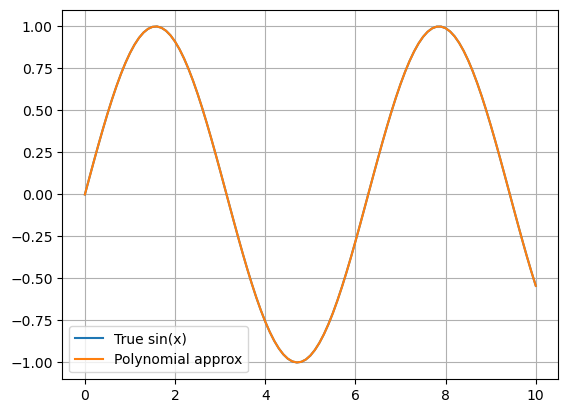

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def predict_poly(x, koeff):
    res = 0
    xx = [x ** (len(koeff) - n - 1) for n in range(len(koeff))]
    for i, k in enumerate(koeff):
        res += k * xx[i]
    return res

x = np.arange(0, 10.1, 0.1)
y = np.sin(x)

x_train, y_train = x[::2], y[::2]

z_train = np.polyfit(x_train, y_train, 10)

y_pred = [predict_poly(val, z_train) for val in x]

plt.plot(x, y, label="True sin(x)")
plt.plot(x, y_pred, label="Polynomial approx")
plt.legend()
plt.grid(True)
plt.show()

Завдання 2

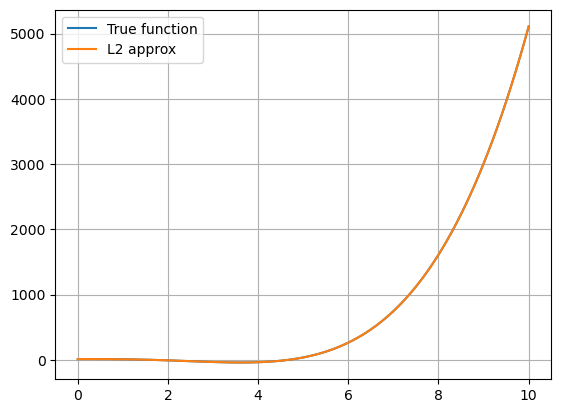

In [2]:
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(0, 10.1, 0.1)
y = np.array([a**4 - 5*a**3 + a**2 + 10 for a in x])

x_train, y_train = x[::2], y[::2]

N = 10
L = 10

X = np.array([[a ** n for n in range(N)] for a in x])
IL = np.eye(N) * L
IL[0][0] = 0

X_train = X[::2]
Y = y_train

A = np.linalg.inv(X_train.T @ X_train + IL)
w = Y @ X_train @ A

yy = [np.dot(w, xi) for xi in X]

plt.plot(x, y, label="True function")
plt.plot(x, yy, label="L2 approx")
plt.legend()
plt.grid(True)
plt.show()

Завдання 3

Weights: [5.21119663e-07 7.39995803e-07 1.07962112e-02 1.76584000e-02
 1.42273056e-02]


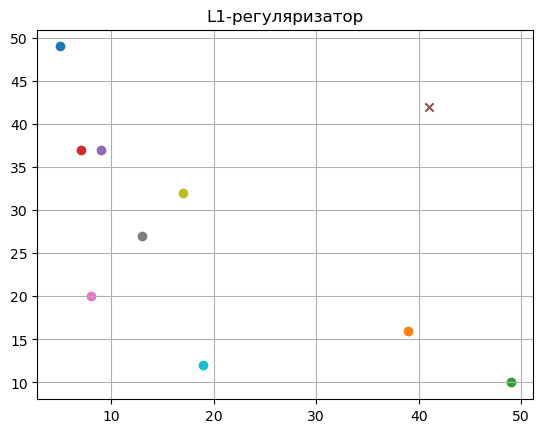

In [2]:
import numpy as np
import matplotlib.pyplot as plt

x_train = np.array([
 [5,49],[39,16],[49,10],[7,37],[9,37],
 [41,42],[8,20],[13,27],[17,32],[19,12]
])

y_train = np.array([1,1,1,1,1,-1,1,1,1,1])

x_train = np.array([list(x) + [10*x[0], 10*x[1], 5*(x[0]+x[1])] for x in x_train])

def loss(w, x, y):
    M = np.dot(w, x) * y
    return 2 / (1 + np.exp(M))

def df(w, x, y):
    L1 = 0.1
    M = np.dot(w, x) * y
    return -2 * np.exp(M) / (1 + np.exp(M))**2 * x * y + L1 * np.sign(w)

fn = len(x_train[0])
w = np.zeros(fn)

nt = 0.00001
lm = 0.01
N = 5000

Q = np.mean([loss(w, x, y) for x, y in zip(x_train, y_train)])
Q_plot = [Q]

for i in range(N):
    k = np.random.randint(0, len(x_train))
    w -= nt * df(w, x_train[k], y_train[k])
    ek = loss(w, x_train[k], y_train[k])
    Q = lm * ek + (1 - lm) * Q
    Q_plot.append(Q)

print("Weights:", w)

for i in range(len(x_train)):
    if y_train[i] == 1:
        plt.scatter(x_train[i][0], x_train[i][1])
    else:
        plt.scatter(x_train[i][0], x_train[i][1], marker='x')

plt.grid(True)
plt.title("L1-регуляризатор")
plt.show()

## Контрольні питання

## 1. Що таке L2-регуляризатор, і як він використовується в задачах регресії та класифікації?
L2-регуляризація додає до основної функції втрат штраф, пропорційний квадрату норми вектора ваг:$$L_{reg}(w) = L(w) + \frac{\lambda}{2} \|w\|^2_2 = L(w) + \frac{\lambda}{2} \sum_{j=1}^{d} w_j^2$$
<br> У регресії мінімізує середньоквадратичну помилку, не дозволяючи коефіцієнтам ставати занадто великими. Це робить модель стійкою до мультиколінеарності.
<br> У класифікації допомагає уникнути перенавчання, роблячи межу розділення класів «гладшою».
## 2. Яка основна відмінність між L1- та L2-регуляризаторами у задачах машинного навчання?
L2 (Ridge) штрафує великі ваги, змушуючи їх бути малими, але не зануляє їх повністю. Кожна ознака зберігає хоча б мінімальний вплив.
<br> L1 (Lasso) використовує модуль ваг ($|w|$). Через геометричні особливості (ромбоподібні контури) вона часто зануляє ваги найменш важливих ознак. Це робить L1 ідеальним інструментом для автоматичного відбору ознак.
## 3. Яким чином можна реалізувати простий лінійний бінарний класифікатор за допомогою стохастичного градієнтного спуску в Python?
Ось спрощений приклад для розуміння логіки оновлення ваг:
<br> ` import numpy as np `
<br> ` def train_sgd(X, y, lr=0.01, epochs=100):`
<br> `    X = np.c_[np.ones(X.shape[0]), X] `
<br> `    w = np.zeros(X.shape[1]) `
<br> `    for _ in range(epochs): `
<br> `        for i in range(X.shape[0]): `
<br> `            prediction = 1 if np.dot(w, X[i]) >= 0 else 0 `
<br> `            error = y[i] - prediction `
<br> `            w += lr * error * X[i] `
<br> `    return w `
## 4. Що таке стохастичний градієнтний спуск, і в чому полягає його використання для оптимізації функціонала якості?
На відміну від звичайного градієнтного спуску, який обчислює градієнт по всьому датасету, SGD обчислює його лише на основі одного випадкового об'єкта (або міні-батчу).
## 5. Як впливає використання регуляризаторів (L1 та L2) на процес навчання моделі і на її загальну ефективність в задачах класифікації та регресії?
Боротьба з Overfitting
<br> Регуляризація вводить «штраф за складність», не даючи моделі ідеально підлаштовуватися під шум у навчальній вибірці.
<br> Зміщення та дисперсія (Bias-Variance Tradeoff) 
<br> Вона трохи збільшує помилку на навчальних даних (зміщення), але значно зменшує розкид результатів на нових даних (дисперсія), що покращує загальну ефективність.